Connection MSSQL

In [1]:
from sqlalchemy import create_engine, text
import urllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


server = r"localhost"
database = "LogistikDB"

connection_string = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={connection_string}"
)

In [2]:
query = """
SELECT 
    TABLE_SCHEMA,
    TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
ORDER BY TABLE_SCHEMA, TABLE_NAME
"""

with engine.connect() as conn:
    result = conn.execute(text(query))
    
    for row in result:
        print(f"{row[0]}.{row[1]}")

dbo.ShippingLogistics
dbo.ShippingLogistics_Analysis
dbo.ShippingLogistics_Analysist
dbo.ShippingLogistics_Cleaned
dbo.ShippingLogistics_Cleaning


Load Data & Understanding

In [3]:
query = """
SELECT *
FROM dbo.ShippingLogistics_Cleaned
"""

df = pd.read_sql(query, engine)
df.to_csv(
    r'C:\Users\Piko\Desktop\SLQ\TableAnalysis.csv',
    index=False
)   
#df = pd.read_csv('LogistikPengiriman.csv')

print('Jumlah baris :', len(df))
print('Jumlah kolom:', len(df.columns))
pd.set_option('display.max_columns', None)
df.head(5)


Jumlah baris : 6000
Jumlah kolom: 24


,ShipmentSK,OrderID,OrderDate,PickupDate,DeliveryDate,OriginCity,DestinationCity,DistanceKM,WeightKG,VolumeM3,Carrier,ShippingType,VehicleType,CustomerType,PaymentMethod,WarehouseID,DriverID,ShippingCostIDR,FuelSurchargeIDR,PlannedDeliveryDays,ActualDeliveryDays,DeliveryStatus,DelayReason,CustomerRating
0,1,ORD2023005830,2025-08-16,2025-08-17,2025-08-24,MAKASSAR,SEMARANG,1173.2,7.11,0.031,ID Express,Instant,Kontainer 20ft,B2C,COD,WH-MED-02,DRV-214,93200.0,2290.0,3,7.0,Returned,Penerima menolak,NaN
1,2,ORD2023004005,2025-01-08,2025-01-09,2025-01-13,PEKANBARU,YOGYAKARTA,1587.9,2.88,0.014,Ninja Xpress,Express,Truk Fuso,B2C,Virtual Account,WH-MAK-02,DRV-428,58900.0,3260.0,4,4.0,Delivered,No Delay,4.0
2,3,ORD2023003417,2024-09-19,2024-09-19,2024-09-26,PALEMBANG,BALIKPAPAN,1496.0,19.83,0.072,ID Express,Ekonomi,Truk CDD,B2B,Kartu Kredit,WH-MED-02,DRV-339,79900.0,1910.0,3,7.0,Returned,Barang rusak,NaN
3,4,ORD2023000608,2025-08-05,2025-08-06,2025-08-09,BANJARMASIN,MANADO,1424.6,21.80,0.195,SiCepat,Reguler,Van,B2B,Kartu Kredit,WH-JAK-01,DRV-219,66700.0,4070.0,3,3.0,Delivered,No Delay,3.0
4,5,ORD2023001342,2025-07-17,2025-07-17,2025-07-26,MAKASSAR,PEKANBARU,2373.3,40.43,0.127,Wahana,Ekonomi,Kontainer 20ft,B2B,E-Wallet,WH-MED-02,DRV-484,158100.0,4980.0,9,9.0,Delivered,No Delay,5.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ShipmentSK           6000 non-null   int64  
 1   OrderID              6000 non-null   str    
 2   OrderDate            6000 non-null   object 
 3   PickupDate           6000 non-null   object 
 4   DeliveryDate         5807 non-null   object 
 5   OriginCity           6000 non-null   str    
 6   DestinationCity      6000 non-null   str    
 7   DistanceKM           6000 non-null   float64
 8   WeightKG             6000 non-null   float64
 9   VolumeM3             6000 non-null   float64
 10  Carrier              6000 non-null   str    
 11  ShippingType         6000 non-null   str    
 12  VehicleType          6000 non-null   str    
 13  CustomerType         6000 non-null   str    
 14  PaymentMethod        6000 non-null   str    
 15  WarehouseID          6000 non-null   str    
 16 

In [5]:
df['TotalShippingCostIDR'] = (
    df['ShippingCostIDR'] + df['FuelSurchargeIDR']
)
df['DeliveredStatus'] = np.where(
    df['DeliveryStatus'] != 'Delivered',
    pd.NA,
    np.where(
        df['ActualDeliveryDays'] > df['PlannedDeliveryDays'],
        'Late',
        'Ontime'
    )
)
df['Route'] = (
    df['OriginCity'] + ' → ' +
    df['DestinationCity']
)

df['CostPerKM'] = (
    df['TotalShippingCostIDR']
    / df['DistanceKM']
)

df['CostPerKG'] = (
    df['TotalShippingCostIDR']
    / df['WeightKG']
)

df['DelayDays'] = (
    df['ActualDeliveryDays'] - 
    df['PlannedDeliveryDays']
)

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df.head(10)

,ShipmentSK,OrderID,OrderDate,PickupDate,DeliveryDate,OriginCity,DestinationCity,DistanceKM,WeightKG,VolumeM3,Carrier,ShippingType,VehicleType,CustomerType,PaymentMethod,WarehouseID,DriverID,ShippingCostIDR,FuelSurchargeIDR,PlannedDeliveryDays,ActualDeliveryDays,DeliveryStatus,DelayReason,CustomerRating,TotalShippingCostIDR,DeliveredStatus,Route,CostPerKM,CostPerKG,DelayDays,Year,Month
0,1,ORD2023005830,2025-08-16,2025-08-17,2025-08-24,MAKASSAR,SEMARANG,1173.2,7.11,0.031,ID Express,Instant,Kontainer 20ft,B2C,COD,WH-MED-02,DRV-214,93200.0,2290.0,3,7.0,Returned,Penerima menolak,NaN,95490.0,NaN,MAKASSAR → SEMARANG,81.392772,13430.379747,4.0,2025,8
1,2,ORD2023004005,2025-01-08,2025-01-09,2025-01-13,PEKANBARU,YOGYAKARTA,1587.9,2.88,0.014,Ninja Xpress,Express,Truk Fuso,B2C,Virtual Account,WH-MAK-02,DRV-428,58900.0,3260.0,4,4.0,Delivered,No Delay,4.0,62160.0,Ontime,PEKANBARU → YOGYAKARTA,39.146042,21583.333333,0.0,2025,1
2,3,ORD2023003417,2024-09-19,2024-09-19,2024-09-26,PALEMBANG,BALIKPAPAN,1496.0,19.83,0.072,ID Express,Ekonomi,Truk CDD,B2B,Kartu Kredit,WH-MED-02,DRV-339,79900.0,1910.0,3,7.0,Returned,Barang rusak,NaN,81810.0,NaN,PALEMBANG → BALIKPAPAN,54.685829,4125.567322,4.0,2024,9
3,4,ORD2023000608,2025-08-05,2025-08-06,2025-08-09,BANJARMASIN,MANADO,1424.6,21.80,0.195,SiCepat,Reguler,Van,B2B,Kartu Kredit,WH-JAK-01,DRV-219,66700.0,4070.0,3,3.0,Delivered,No Delay,3.0,70770.0,Ontime,BANJARMASIN → MANADO,49.677102,3246.330275,0.0,2025,8
4,5,ORD2023001342,2025-07-17,2025-07-17,2025-07-26,MAKASSAR,PEKANBARU,2373.3,40.43,0.127,Wahana,Ekonomi,Kontainer 20ft,B2B,E-Wallet,WH-MED-02,DRV-484,158100.0,4980.0,9,9.0,Delivered,No Delay,5.0,163080.0,Ontime,MAKASSAR → PEKANBARU,68.714448,4033.638387,0.0,2025,7
5,6,ORD2023000986,2024-05-30,2024-05-31,2024-06-03,BANJARMASIN,BANDUNG,1144.3,11.20,0.091,Wahana,Reguler,Truk CDD,B2C,COD,WH-MAK-02,DRV-153,56900.0,1610.0,3,3.0,Delivered,No Delay,1.0,58510.0,Ontime,BANJARMASIN → BANDUNG,51.131696,5224.107143,0.0,2024,5
6,7,ORD2023002409,2025-04-11,2025-04-12,2025-04-19,MEDAN,SURABAYA,2626.2,5.46,0.012,J&T Express,Express,Kontainer 20ft,B2C,E-Wallet,WH-JAK-02,DRV-215,92300.0,2710.0,7,7.0,Delivered,No Delay,4.0,95010.0,Ontime,MEDAN → SURABAYA,36.177747,17401.098901,0.0,2025,4
7,8,ORD2023000826,2023-12-20,2023-12-20,2023-12-21,SEMARANG,MALANG,324.9,9.37,0.085,Lion Parcel,Express,Truk CDD,B2C,Kartu Kredit,WH-MED-01,DRV-404,60800.0,4190.0,1,1.0,Delivered,No Delay,1.0,64990.0,Ontime,SEMARANG → MALANG,200.030779,6935.965848,0.0,2023,12
8,9,ORD2023001105,2023-06-05,2023-06-05,None,MEDAN,BATAM,824.0,26.73,0.062,GoSend Logistics,Reguler,Truk Fuso,B2C,Kartu Kredit,WH-MAK-02,DRV-234,132500.0,3490.0,2,NaN,Lost,Barang hilang dalam pengiriman,NaN,135990.0,NaN,MEDAN → BATAM,165.036408,5087.542088,NaN,2023,6
9,10,ORD2023001179,2023-02-18,2023-02-18,2023-02-25,PEKANBARU,SURABAYA,1981.5,0.62,0.006,SiCepat,Reguler,Motor,B2C,Transfer Bank,WH-SUR-02,DRV-201,32000.0,2470.0,5,7.0,Delayed,Kepadatan lalu lintas,1.0,34470.0,NaN,PEKANBARU → SURABAYA,17.395912,55596.774194,2.0,2023,2


Analysist

In [6]:
totalshipments = len(df)

delivered = (df['DeliveryStatus'] == 'Delivered').sum()
delayed = (df['DeliveryStatus'] == 'Delayed').sum()
returned = (df['DeliveryStatus'] == 'Returned').sum()
lost = (df['DeliveryStatus'] == 'Lost').sum()

deliveryrate = delivered / totalshipments
delayrate = delayed / totalshipments
returnrate = returned / totalshipments
lostrate = lost / totalshipments

totalcost = df['TotalShippingCostIDR'].sum()
avgcost = df['TotalShippingCostIDR'].mean()

avgdistance = df['DistanceKM'].mean()
avgweight = df['WeightKG'].mean()
avgrating = df['CustomerRating'].mean()

kpi = pd.DataFrame({
    'Metric': [
        'Total Shipments',
        'Delivered Rate',
        'Delayed Rate',
        'Returned Rate',
        'Lost Rate',
        'Total Shipping Cost',
        'Average Shipping Cost',
        'Average Distance',
        'Average Weight',
        'Average Rating'
    ],
    'Value': [
        totalshipments,
        deliveryrate,
        delayrate,
        returnrate,
        lostrate,
        totalcost,
        avgcost,
        avgdistance,
        avgweight,
        avgrating
    ]
})
pd.set_option('display.float_format', '{:,.2f}'.format)
print(kpi)

                  Metric          Value
0        Total Shipments       6,000.00
1         Delivered Rate           0.67
2           Delayed Rate           0.23
3          Returned Rate           0.07
4              Lost Rate           0.03
5    Total Shipping Cost 672,858,255.32
6  Average Shipping Cost     112,143.04
7       Average Distance       1,328.48
8         Average Weight          16.96
9         Average Rating           3.42


Monthly Performance

In [7]:
monthly = (
    df.groupby(['Year', 'Month'])
    .agg(
        Shipments=('OrderID', 'count'),
        AvgCost=('TotalShippingCostIDR', 'mean'),
        AvgDeliveryDays=('ActualDeliveryDays', 'mean'),
        AvgRating=('CustomerRating', 'mean'),
        MonthYear=('OrderDate', lambda x: x.dt.to_period('M').iloc[0].strftime('%b %Y'))
    )
    .reset_index()
)
monthly['GrowthRate'] = monthly['Shipments'].pct_change() * 100 
monthly['GrowthRate'] = monthly['GrowthRate'].map('{:.2f}%'.format)
monthly.head(len(monthly))

,Year,Month,Shipments,AvgCost,AvgDeliveryDays,AvgRating,MonthYear,GrowthRate
0,2023,1,182,"103,541.51",5.00,3.53,Jan 2023,nan%
1,2023,2,154,"89,407.66",4.52,3.44,Feb 2023,-15.38%
2,2023,3,178,"138,007.95",4.25,3.53,Mar 2023,15.58%
3,2023,4,148,"169,587.47",4.74,3.50,Apr 2023,-16.85%
4,2023,5,164,"100,656.89",4.89,3.39,May 2023,10.81%
5,2023,6,157,"136,048.42",4.95,3.42,Jun 2023,-4.27%
6,2023,7,153,"93,139.87",4.63,3.43,Jul 2023,-2.55%
7,2023,8,146,"120,275.75",4.93,3.23,Aug 2023,-4.58%
8,2023,9,159,"94,219.25",5.05,3.51,Sep 2023,8.90%
9,2023,10,157,"98,685.86",5.39,3.36,Oct 2023,-1.26%


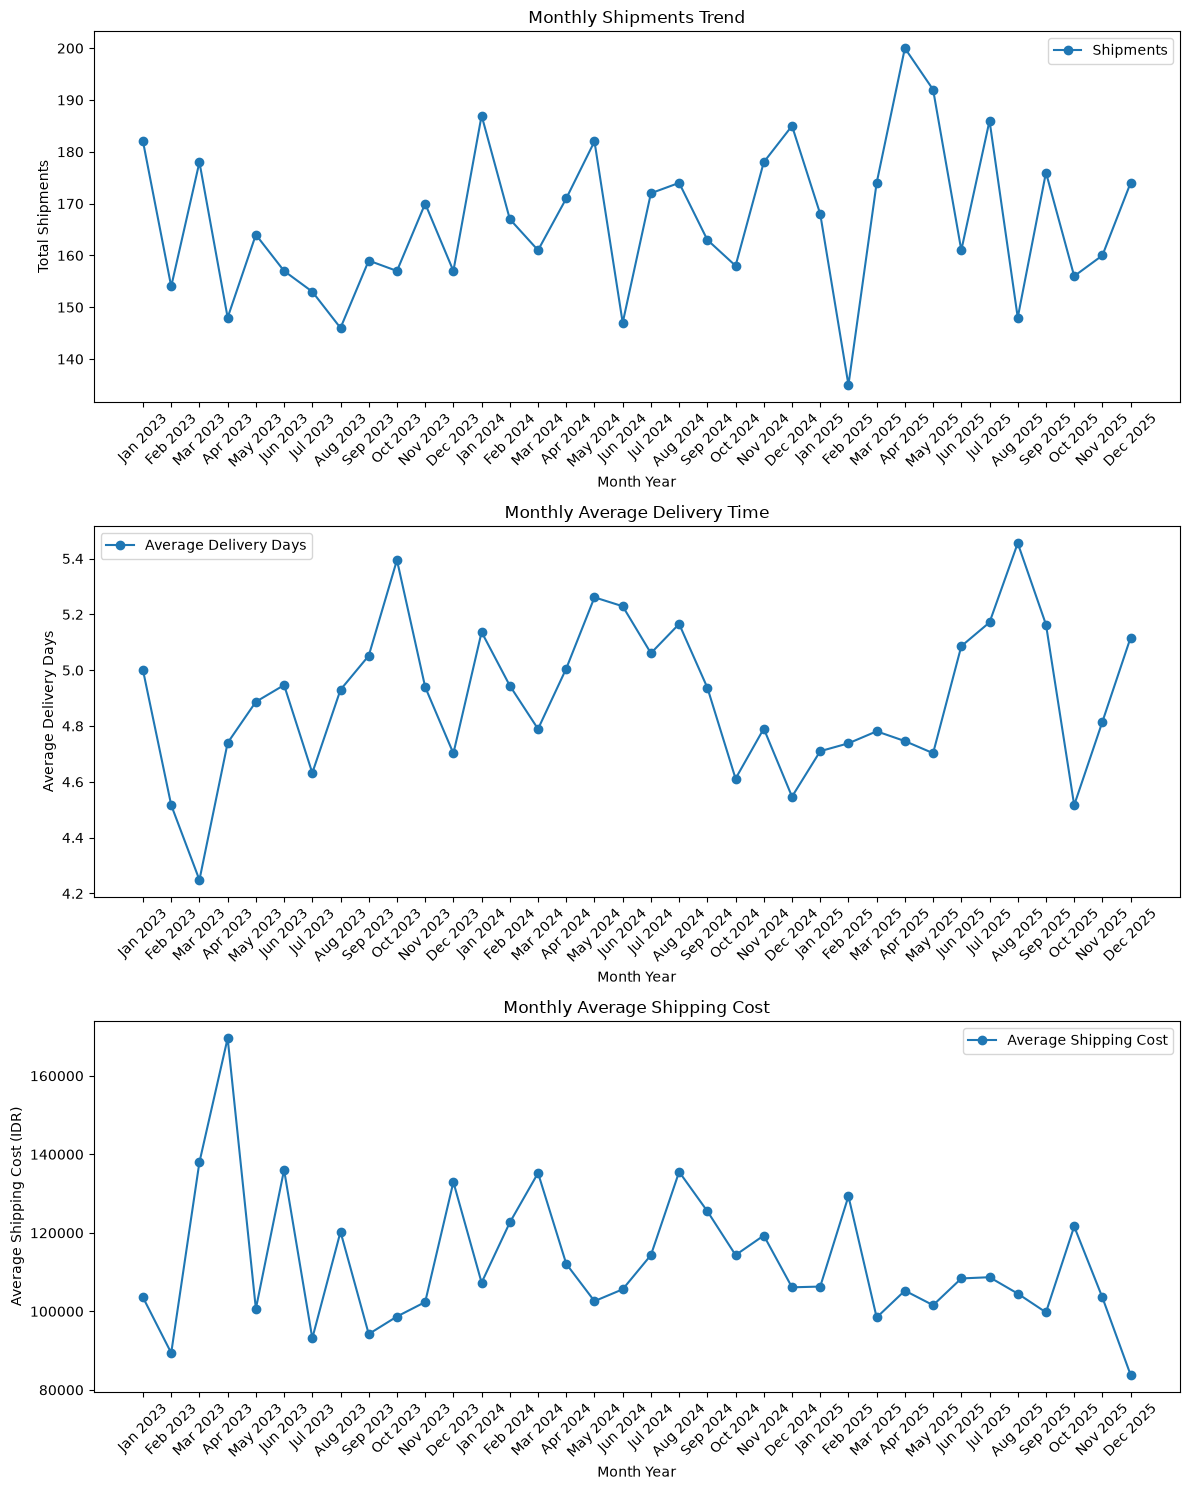

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(12, 15))

# 1. Monthly Shipments
ax[0].plot(
    monthly['MonthYear'],
    monthly['Shipments'],
    marker='o',
    label='Shipments'
)
ax[0].set_xlabel('Month Year')
ax[0].set_ylabel('Total Shipments')
ax[0].set_title('Monthly Shipments Trend')
ax[0].legend()
ax[0].tick_params(axis='x', rotation=45)


# 2. Average Delivery Days
ax[1].plot(
    monthly['MonthYear'],
    monthly['AvgDeliveryDays'],
    marker='o',
    label='Average Delivery Days'
)
ax[1].set_xlabel('Month Year')
ax[1].set_ylabel('Average Delivery Days')
ax[1].set_title('Monthly Average Delivery Time')
ax[1].legend()
ax[1].tick_params(axis='x', rotation=45)


# 3. Average Shipping Cost
ax[2].plot(
    monthly['MonthYear'],
    monthly['AvgCost'],
    marker='o',
    label='Average Shipping Cost'
)
ax[2].set_xlabel('Month Year')
ax[2].set_ylabel('Average Shipping Cost (IDR)')
ax[2].set_title('Monthly Average Shipping Cost')
ax[2].legend()
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Delivery Status Performance

In [9]:
deliveryoutcome = (
    df.groupby('DeliveryStatus')
    .agg(
        Shipments = ('OrderID', 'count'),
        ShipmentsContribution = ('DeliveryStatus', lambda x: len(x)/totalshipments *100 ),
        AvgPlannedDays=('PlannedDeliveryDays', 'mean'),
        AvgActualDays=('ActualDeliveryDays', 'mean'),
        Rating = ('CustomerRating', 'mean')
    ).reset_index()
)
deliveryoutcome['ShipmentsContribution'] = deliveryoutcome['ShipmentsContribution'].map('{:.2f}%'.format)
deliveryoutcome.head().sort_values(by='Shipments', ascending=False)


,DeliveryStatus,Shipments,ShipmentsContribution,AvgPlannedDays,AvgActualDays,Rating
1,Delivered,4034,67.23%,3.69,3.94,3.90
0,Delayed,1366,22.77%,3.78,6.78,2.00
3,Returned,407,6.78%,3.60,8.10,NaN
2,Lost,193,3.22%,3.55,NaN,NaN


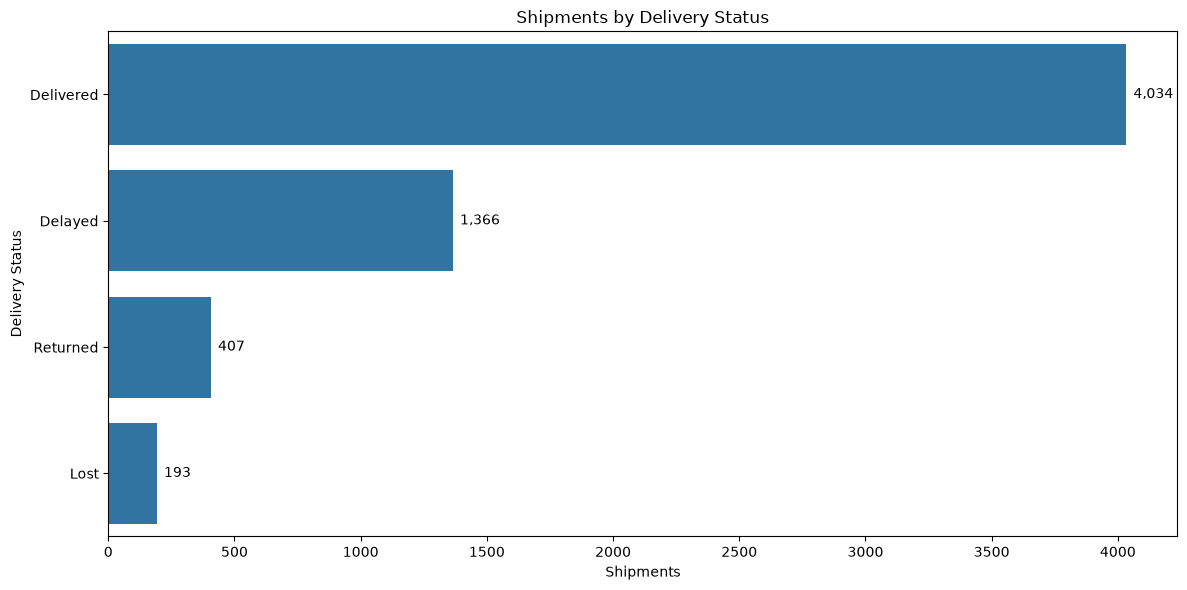

In [10]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=deliveryoutcome.sort_values(by='Shipments',ascending=False),
    x='Shipments',
    y='DeliveryStatus'
)

plt.title('Shipments by Delivery Status')
plt.xlabel('Shipments')
plt.ylabel('Delivery Status')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

In [11]:
deliveredtiming = (
    df.groupby('DeliveredStatus')
    .agg(
        Shipments=('DeliveredStatus', 'count'),
        Percentage=('DeliveredStatus', lambda x: len(x) / delivered * 100)
    ).reset_index()
)
deliveredtiming['Percentage'] = deliveredtiming['Percentage'].map('{:.2f}'.format)
deliveredtiming.head()


,DeliveredStatus,Shipments,Percentage
0,Late,1039,25.76
1,Ontime,2995,74.24


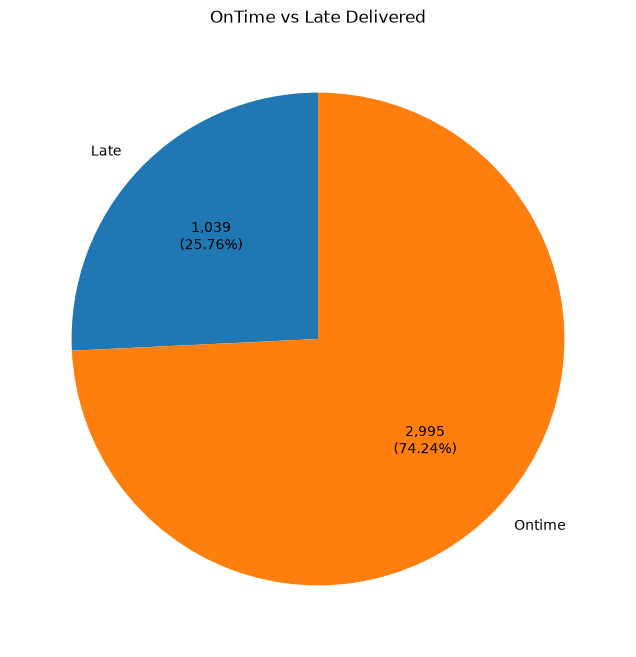

In [12]:
plt.figure(figsize=(8, 8))

plt.pie(
    deliveredtiming['Shipments'],
    labels=deliveredtiming['DeliveredStatus'],
    autopct=lambda pct: f'{int(round(pct / 100 * deliveredtiming["Shipments"].sum())):,}\n({pct:.2f}%)',
    startangle=90
)

plt.title('OnTime vs Late Delivered')
plt.show()

In [13]:
df['DeliveryIssue'] = np.where(
    df['DeliveryStatus'].isin(['Delayed','Returned','Lost']),
    1,
    0
)
delivery_issue_count = (
    df['DeliveryIssue'].sum()
)
delivery_issue_rate = (
    df['DeliveryIssue'].mean() * 100
)

print(f"Delivery Issue Count: {delivery_issue_count}")
print(f"Delivery Issue Rate: {delivery_issue_rate:.2f}%")

Delivery Issue Count: 1966
Delivery Issue Rate: 32.77%


In [14]:
issuereason = (
    df[df['DeliveryStatus'] != 'Delivered']
    .groupby('DelayReason')
    .agg(
        Shipments = ('DelayReason', 'count'),
        Percentage = ('DelayReason', lambda x : len(x)/(delayed+returned+lost) * 100)
    )
    .reset_index()
)
issuereason['Percentage'] = issuereason['Percentage'].map('{:.2f}%'.format)
issuereason = issuereason.rename(columns={
    'DelayReason': 'IssueReason'
})
issuereason.sort_values(by='Shipments', ascending=False)

,IssueReason,Shipments,Percentage
8,Kesalahan alamat,214,10.89%
3,Cuaca buruk,203,10.33%
5,Kendala armada,199,10.12%
1,Barang hilang dalam pengiriman,193,9.82%
4,Kapasitas armada penuh,189,9.61%
6,Kendala bea cukai,189,9.61%
9,Keterlambatan sortir gudang,188,9.56%
7,Kepadatan lalu lintas,184,9.36%
10,Penerima menolak,141,7.17%
2,Barang rusak,133,6.77%


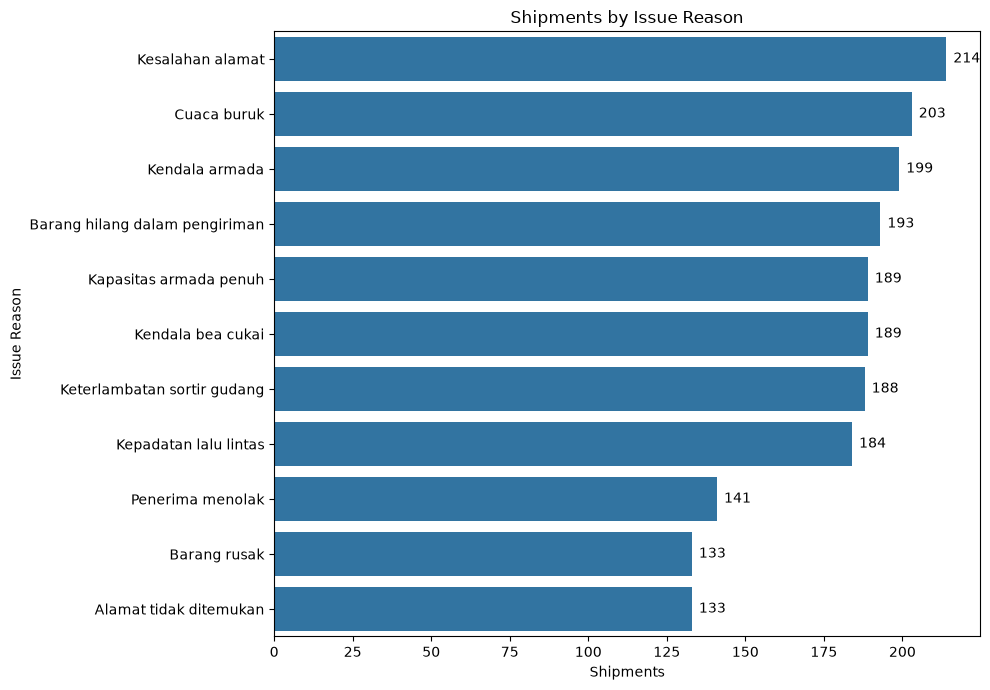

In [15]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=issuereason.sort_values(by='Shipments', ascending=False),
    x='Shipments',
    y='IssueReason'
)

plt.title('Shipments by Issue Reason')
plt.xlabel('Shipments')
plt.ylabel('Issue Reason')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

In [16]:
#Delayed status analysis
delayeddf = (
    df[df['DeliveryStatus'] == 'Delayed']
    .groupby('DelayReason')
    .agg(
        DelayedShipments = ('OrderID', 'count'),
        AVGDelayDays = ('DelayDays', 'mean') 
    )
)
delayeddf.head(len(delayeddf))


,DelayedShipments,AVGDelayDays
DelayReason,,
Cuaca buruk,203,2.94
Kapasitas armada penuh,189,2.83
Kendala armada,199,2.95
Kendala bea cukai,189,3.03
Kepadatan lalu lintas,184,2.98
Kesalahan alamat,214,3.17
Keterlambatan sortir gudang,188,3.11


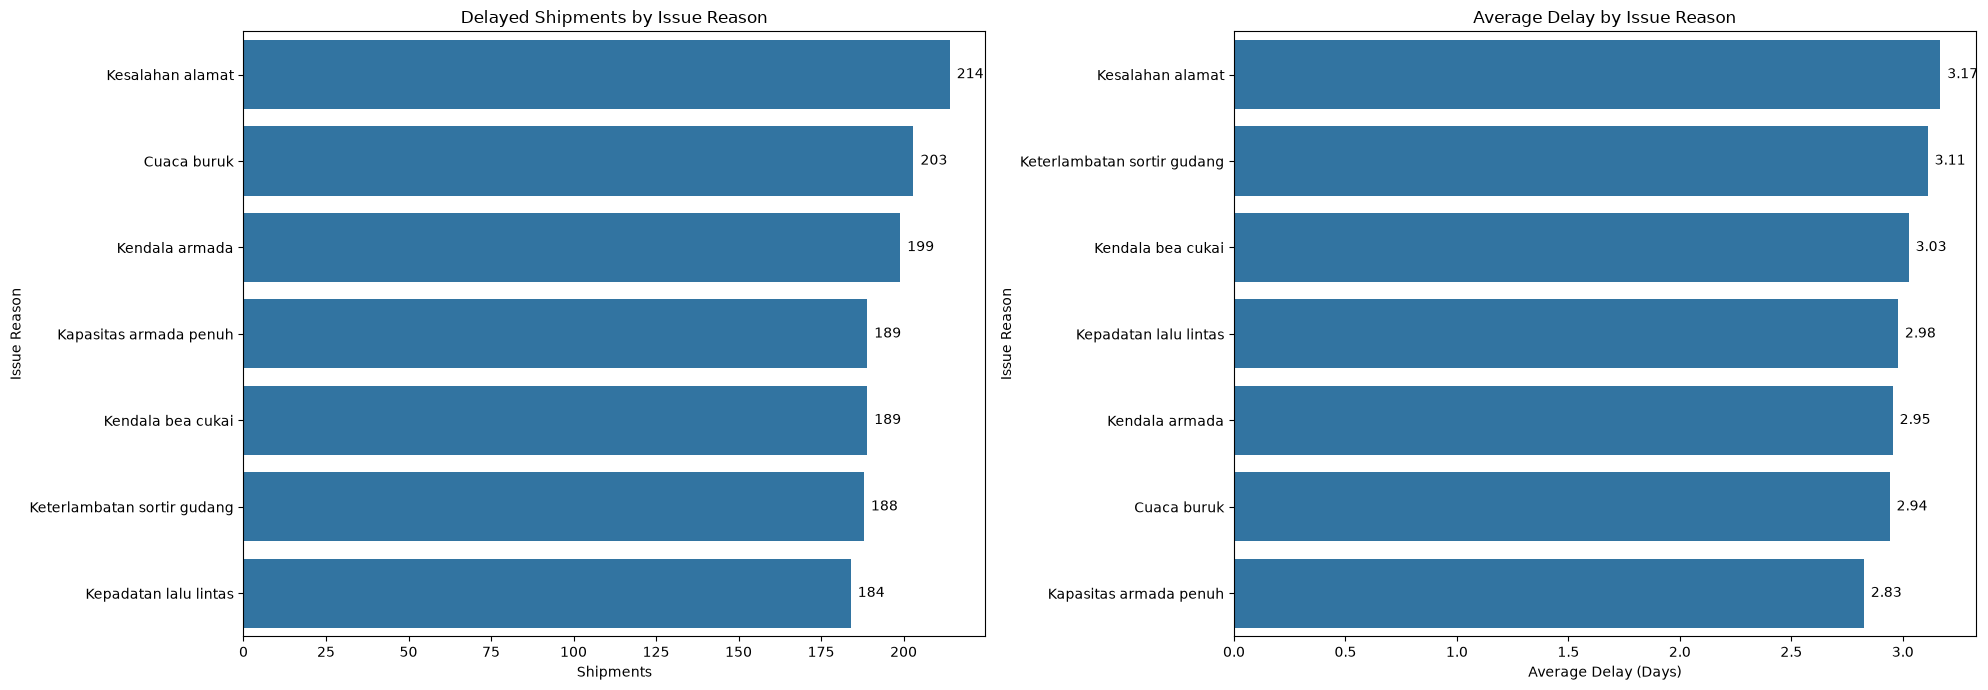

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ax1 = sns.barplot(
    data=delayeddf.sort_values(by='DelayedShipments',ascending=False),
    x='DelayedShipments',
    y='DelayReason',
    ax=axes[0]
)

ax1.set_title('Delayed Shipments by Issue Reason')
ax1.set_xlabel('Shipments')
ax1.set_ylabel('Issue Reason')

ax1.bar_label(
    ax1.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax1.containers[0].datavalues
    ],
    padding=5
)

ax2 = sns.barplot(
    data=delayeddf.sort_values(by='AVGDelayDays',ascending=False),
    x='AVGDelayDays',
    y='DelayReason',
    ax=axes[1]
)

ax2.set_title('Average Delay by Issue Reason')
ax2.set_xlabel('Average Delay (Days)')
ax2.set_ylabel('Issue Reason')

ax2.bar_label(
    ax2.containers[0],
    labels=[
        f'{v:.2f}'
        for v in ax2.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

In [18]:
#Returned status analysis
returneddf = (
    df[df['DeliveryStatus'] == 'Returned']
    .groupby('DelayReason')
    .agg(
        ReturnedShipments = ('OrderID', 'count') 
    )
)
returneddf.head(len(returneddf))


,ReturnedShipments
DelayReason,
Alamat tidak ditemukan,133
Barang rusak,133
Penerima menolak,141


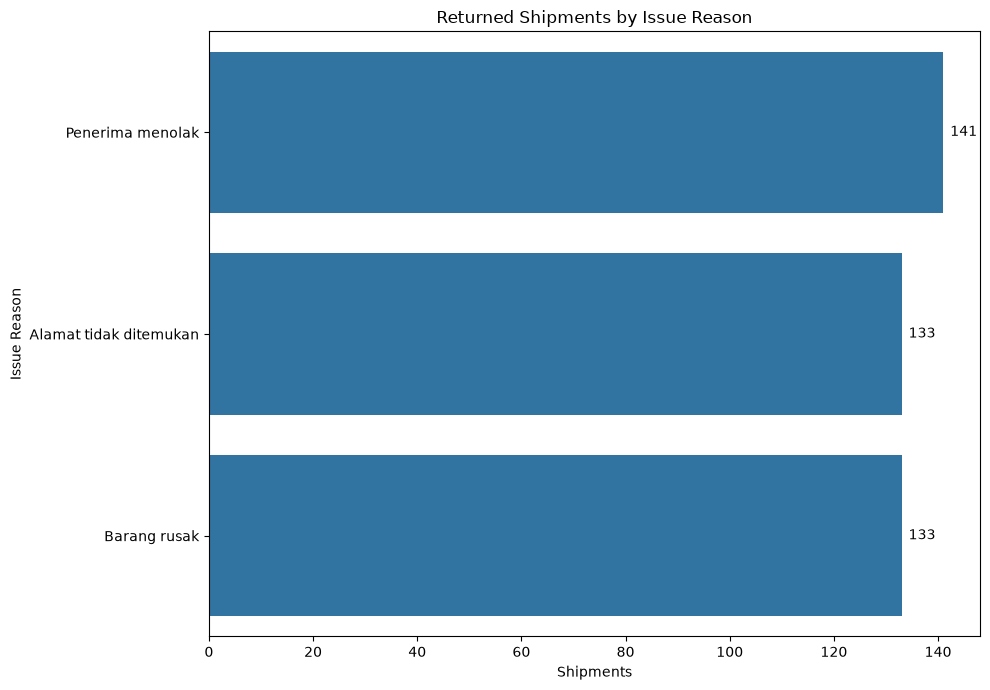

In [19]:
fig = plt.subplots(figsize=(10, 7))

ax = sns.barplot(
    data=returneddf.sort_values(by='ReturnedShipments',ascending=False),
    x='ReturnedShipments',
    y='DelayReason',
)

plt.title('Returned Shipments by Issue Reason')
plt.xlabel('Shipments')
plt.ylabel('Issue Reason')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

In [20]:
#lost status analysis
lostdf = (
    df[df['DeliveryStatus'] == 'Lost']
    .groupby('DelayReason')
    .agg(
        LostShipments = ('OrderID', 'count') 
    )
)
lostdf.head(len(lostdf))


,LostShipments
DelayReason,
Barang hilang dalam pengiriman,193


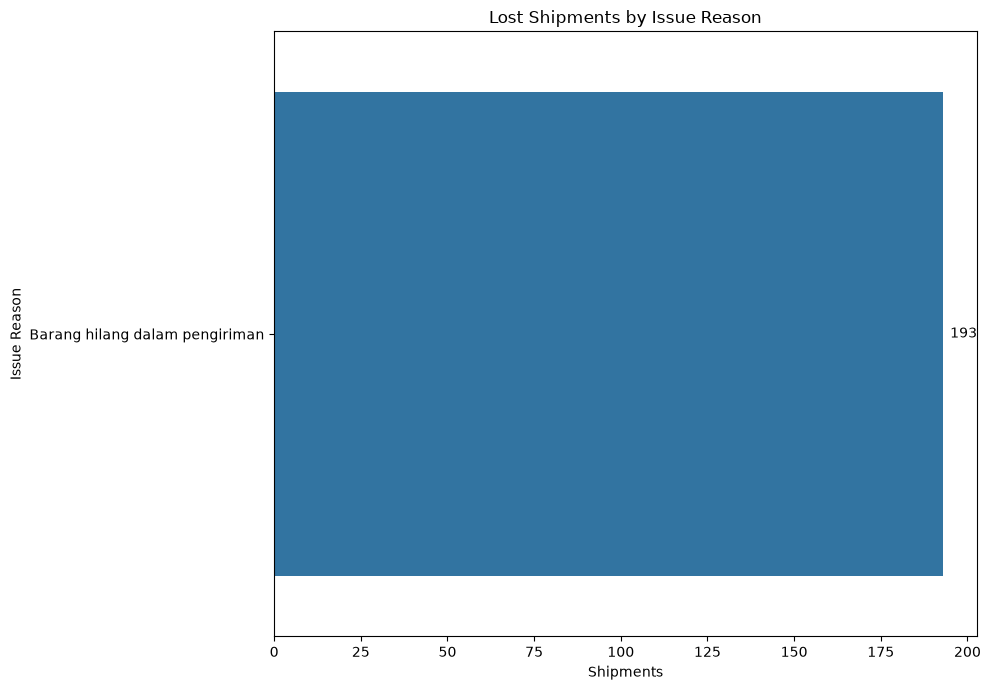

In [21]:
fig = plt.subplots(figsize=(10, 7))

ax = sns.barplot(
    data=lostdf.sort_values(by='LostShipments',ascending=False),
    x='LostShipments',
    y='DelayReason',
)

plt.title('Lost Shipments by Issue Reason')
plt.xlabel('Shipments')
plt.ylabel('Issue Reason')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

Carrier Performance Analysis

In [22]:
carrier = (
    df.groupby('Carrier')
    .agg(
        Shipments = ('OrderID', 'count'),
        CarrierContribution = ('OrderID', lambda x: f"{len(x) / totalshipments * 100:.2f}%"),
        Delivered = ('DeliveryStatus', lambda x: (x == 'Delivered').sum()),
        Delayed = ('DeliveryStatus', lambda x: (x == 'Delayed').sum()),
        Returned = ('DeliveryStatus', lambda x: (x == 'Returned').sum()),
        Lost = ('DeliveryStatus', lambda x: (x == 'Lost').sum()),
        AvgDeliveryDays = ('ActualDeliveryDays', 'mean'),
        AvgRating = ('CustomerRating', 'mean')
    )
    .reset_index()
)
carrier['DeliveredRate'] = (
    carrier['Delivered']
    / carrier['Shipments']
    * 100
)

carrier['DelayedRate'] = (
    carrier['Delayed']
    / carrier['Shipments']
    * 100
)

carrier['ReturnedRate'] = (
    carrier['Returned']
    / carrier['Shipments']
    * 100
)

carrier['LostRate'] = (
    carrier['Lost']
    / carrier['Shipments']
    * 100
)

carrier['IssueRate'] = (
    carrier['Delayed']
    + carrier['Returned']
    + carrier['Lost']
) / carrier['Shipments'] * 100

carrier.head(10).sort_values(by='Shipments', ascending=False)

,Carrier,Shipments,CarrierContribution,Delivered,Delayed,Returned,Lost,AvgDeliveryDays,AvgRating,DeliveredRate,DelayedRate,ReturnedRate,LostRate,IssueRate
3,J&T Express,642,10.70%,454,122,52,14,4.98,3.52,70.72,19.00,8.10,2.18,29.28
0,AnterAja,633,10.55%,435,136,38,24,4.68,3.37,68.72,21.48,6.00,3.79,31.28
7,Pos Indonesia,620,10.33%,404,150,44,22,5.11,3.30,65.16,24.19,7.10,3.55,34.84
2,ID Express,613,10.22%,391,155,43,24,4.96,3.39,63.78,25.29,7.01,3.92,36.22
6,Ninja Xpress,608,10.13%,383,148,54,23,5.01,3.32,62.99,24.34,8.88,3.78,37.01
1,GoSend Logistics,600,10.00%,411,135,39,15,4.93,3.49,68.50,22.50,6.50,2.50,31.50
8,SiCepat,599,9.98%,405,146,29,19,4.94,3.38,67.61,24.37,4.84,3.17,32.39
9,Wahana,588,9.80%,400,131,33,24,4.70,3.54,68.03,22.28,5.61,4.08,31.97
5,Lion Parcel,579,9.65%,406,123,36,14,4.74,3.44,70.12,21.24,6.22,2.42,29.88
4,JNE,518,8.63%,345,120,39,14,4.98,3.43,66.60,23.17,7.53,2.70,33.40


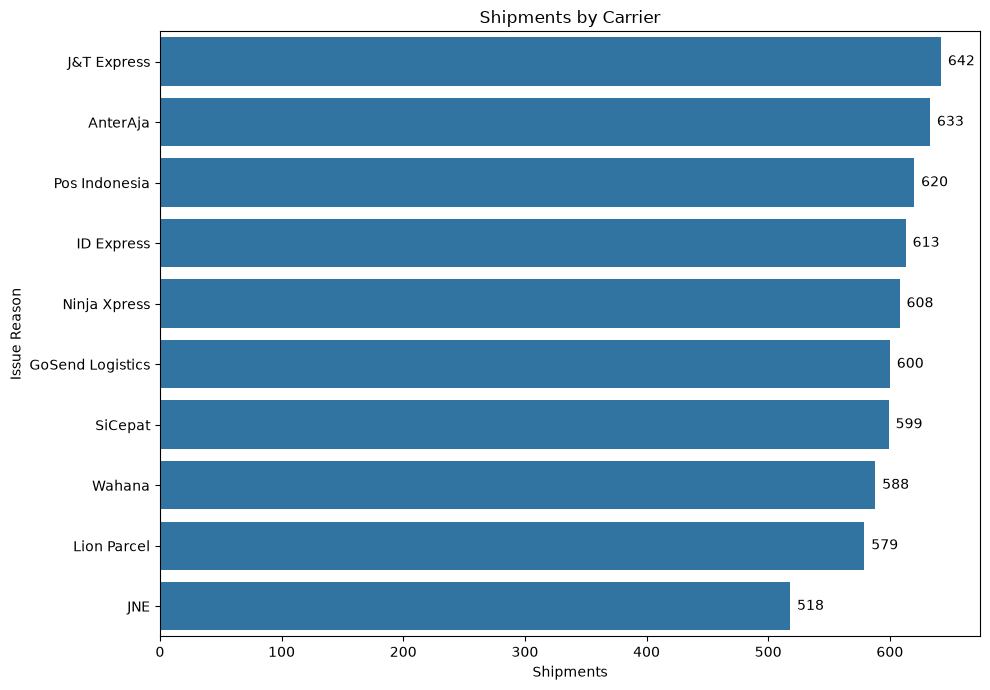

In [23]:
fig = plt.subplots(figsize=(10, 7))

ax = sns.barplot(
    data=carrier.sort_values(by='Shipments',ascending=False),
    x='Shipments',
    y='Carrier',
)

plt.title('Shipments by Carrier')
plt.xlabel('Shipments')
plt.ylabel('Issue Reason')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

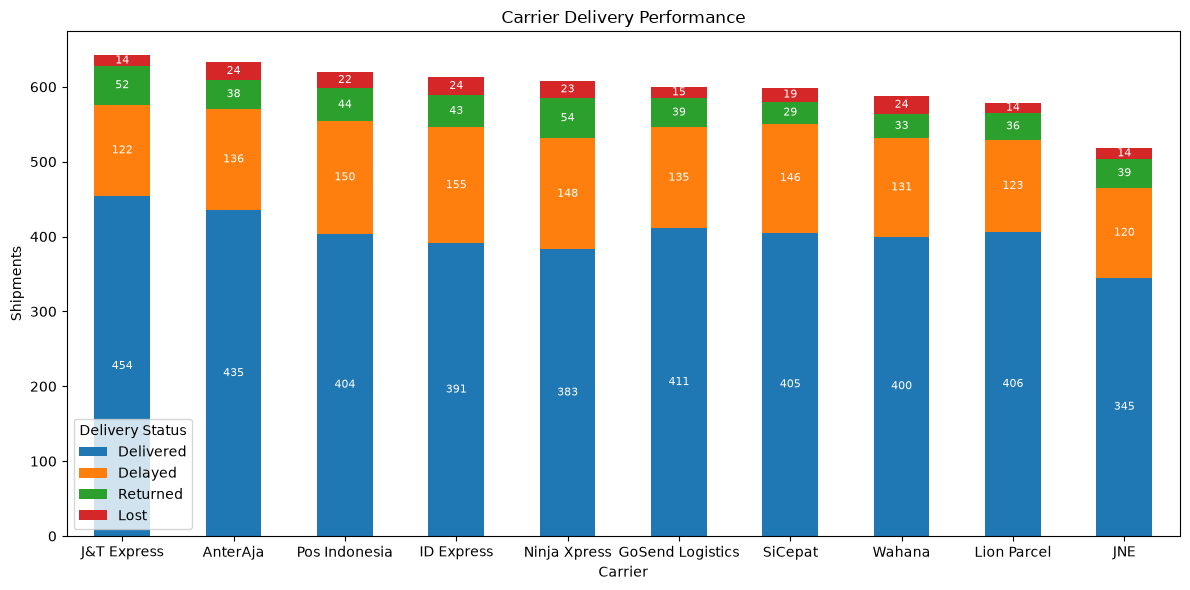

In [24]:
carrier_plot = carrier.sort_values(
    by='Shipments',
    ascending=False
)

ax = carrier_plot.set_index('Carrier')[
    ['Delivered', 'Delayed', 'Returned', 'Lost']
].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Carrier Delivery Performance')
plt.xlabel('Carrier')
plt.ylabel('Shipments')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')

# Label jumlah pada setiap stacked
for container in ax.containers:
    labels = [
        f'{int(v):,}' if v > 0 else ''
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        color='white',
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [25]:
costefficiency = (
    df.groupby('Carrier')
    .agg(
        Shipments=('OrderID', 'count'),
        AvgCost=('TotalShippingCostIDR', 'mean'),
        AvgCostPerKM=('CostPerKM', 'mean'),
        AvgCostPerKG=('CostPerKG', 'mean'),
    ).reset_index()
)

costefficiency.sort_values(by='AvgCost')

,Carrier,Shipments,AvgCost,AvgCostPerKM,AvgCostPerKG
5,Lion Parcel,579,"106,232.95",126.83,"10,429.13"
6,Ninja Xpress,608,"106,734.59",130.96,"12,115.89"
3,J&T Express,642,"107,412.12",123.89,"11,833.07"
0,AnterAja,633,"109,870.23",136.23,"10,502.61"
7,Pos Indonesia,620,"111,736.52",120.23,"12,032.40"
8,SiCepat,599,"112,213.73",147.54,"12,236.69"
9,Wahana,588,"114,685.29",137.45,"11,398.38"
4,JNE,518,"116,470.47",137.65,"10,466.89"
1,GoSend Logistics,600,"117,795.29",145.63,"12,079.80"
2,ID Express,613,"119,105.75",145.95,"11,618.16"


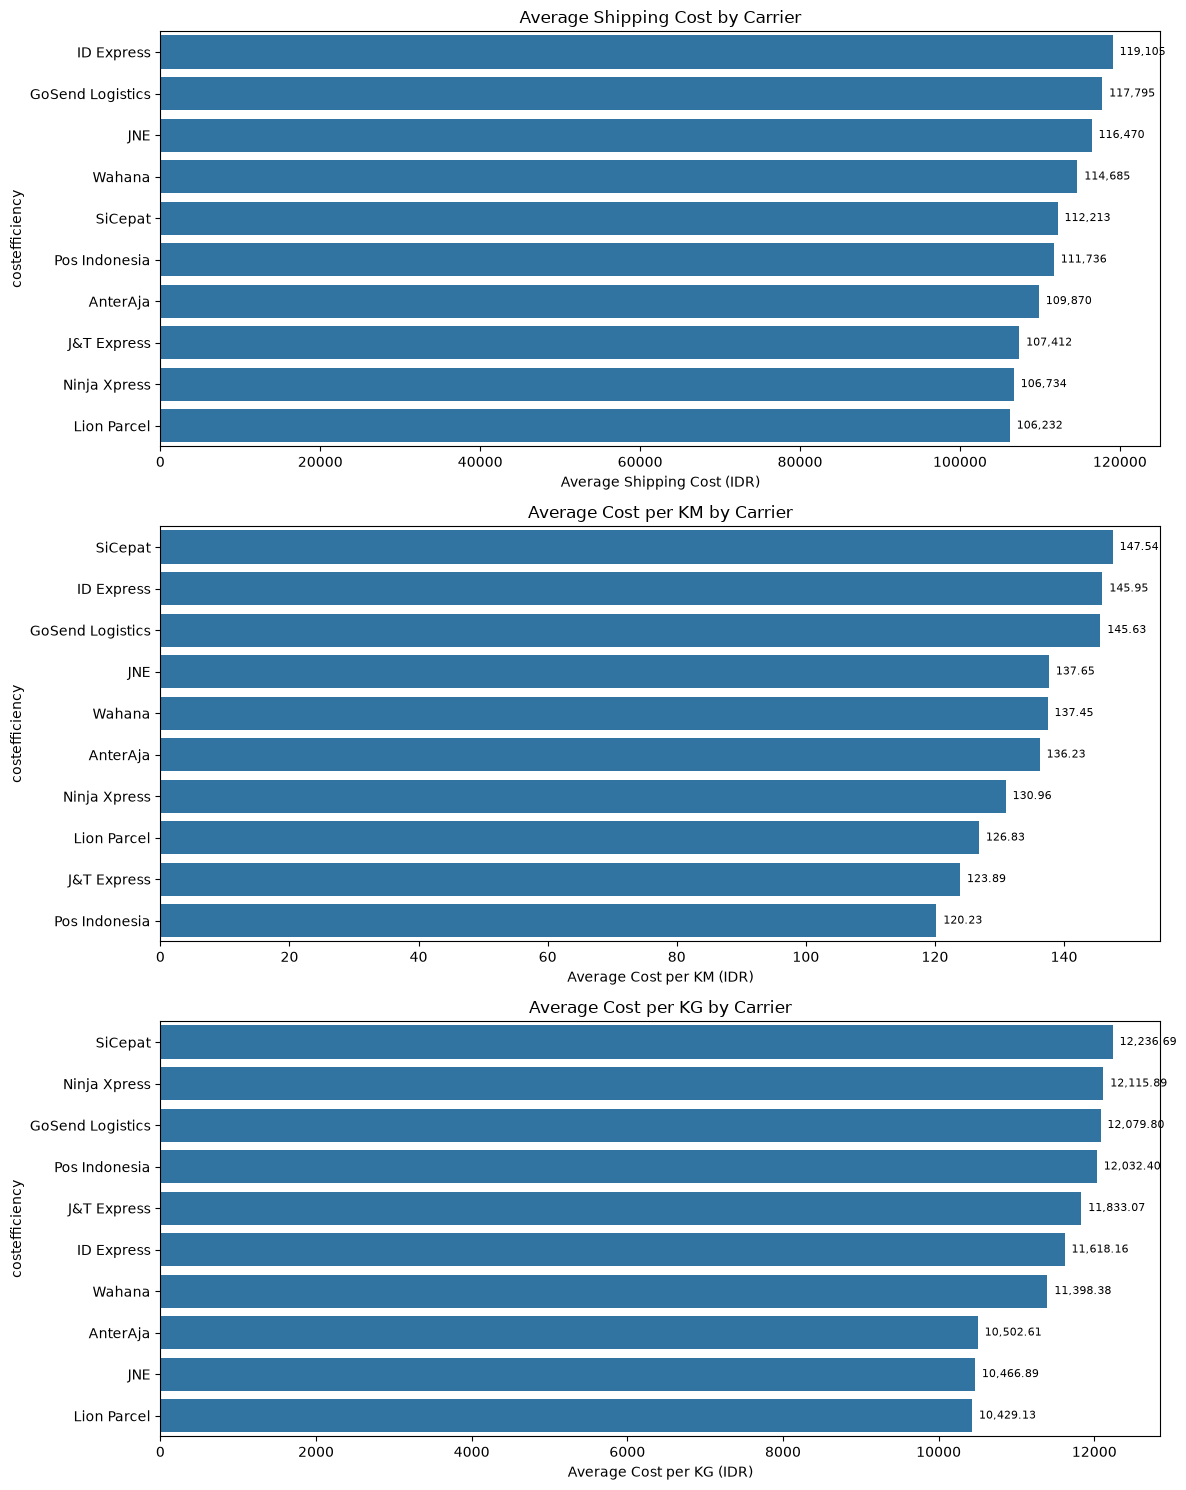

In [26]:
fig, ax = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(data=costefficiency.sort_values(by='AvgCost',ascending=False),
    x='AvgCost',
    y='Carrier',
    ax=ax[0]
)

ax[0].set_title('Average Shipping Cost by Carrier')
ax[0].set_xlabel('Average Shipping Cost (IDR)')
ax[0].set_ylabel('costefficiency')

ax[0].bar_label(
    ax[0].containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax[0].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)


sns.barplot(data=costefficiency.sort_values(by='AvgCostPerKM',ascending=False),
    x='AvgCostPerKM',
    y='Carrier',
    ax=ax[1]
)

ax[1].set_title('Average Cost per KM by Carrier')
ax[1].set_xlabel('Average Cost per KM (IDR)')
ax[1].set_ylabel('costefficiency')

ax[1].bar_label(
    ax[1].containers[0],
    labels=[
        f'{v:,.2f}'
        for v in ax[1].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)


sns.barplot(data=costefficiency.sort_values(by='AvgCostPerKG',ascending=False),
    x='AvgCostPerKG',
    y='Carrier',
    ax=ax[2]
)

ax[2].set_title('Average Cost per KG by Carrier')
ax[2].set_xlabel('Average Cost per KG (IDR)')
ax[2].set_ylabel('costefficiency')

ax[2].bar_label(
    ax[2].containers[0],
    labels=[
        f'{v:,.2f}'
        for v in ax[2].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)

plt.tight_layout()
plt.show()

Shipping Type Performance

In [27]:
shippingtype = (
    df.groupby('ShippingType')
    .agg(
        Shipments=('OrderID', 'count'),
        Contribution = ('OrderID', lambda x: f"{len(x) / totalshipments * 100:.2f}%"),
        Delivered = ('DeliveryStatus', lambda x: (x == 'Delivered').sum()),
        Delayed = ('DeliveryStatus', lambda x: (x == 'Delayed').sum()),
        Returned = ('DeliveryStatus', lambda x: (x == 'Returned').sum()),
        Lost = ('DeliveryStatus', lambda x: (x == 'Lost').sum()),
        AvgCost=('TotalShippingCostIDR', 'mean'),
        AvgCostPerKM=('CostPerKM', 'mean'),
        AvgCostPerKG=('CostPerKG', 'mean'),
        AvgDistance=('DistanceKM', 'mean'),
        AvgDeliveryDays=('ActualDeliveryDays', 'mean'),
        AvgRating=('CustomerRating', 'mean')
    )
    .reset_index()
)
shippingtype.sort_values(by='Shipments', ascending=False)

,ShippingType,Shipments,Contribution,Delivered,Delayed,Returned,Lost,AvgCost,AvgCostPerKM,AvgCostPerKG,AvgDistance,AvgDeliveryDays,AvgRating
4,Reguler,2740,45.67%,1836,623,202,79,"92,513.60",109.05,"9,115.97","1,330.08",4.91,3.43
1,Express,1525,25.42%,1036,350,84,55,"148,660.02",181.34,"15,970.11","1,329.32",4.89,3.39
3,Kargo,866,14.43%,583,188,65,30,"68,376.72",85.04,"6,912.62","1,315.42",4.85,3.47
2,Instant,600,10.00%,397,147,39,17,"197,433.48",238.63,"20,123.84","1,349.15",5.00,3.35
0,Ekonomi,269,4.48%,182,58,17,12,"55,725.39",69.05,"5,728.17","1,303.45",4.88,3.42


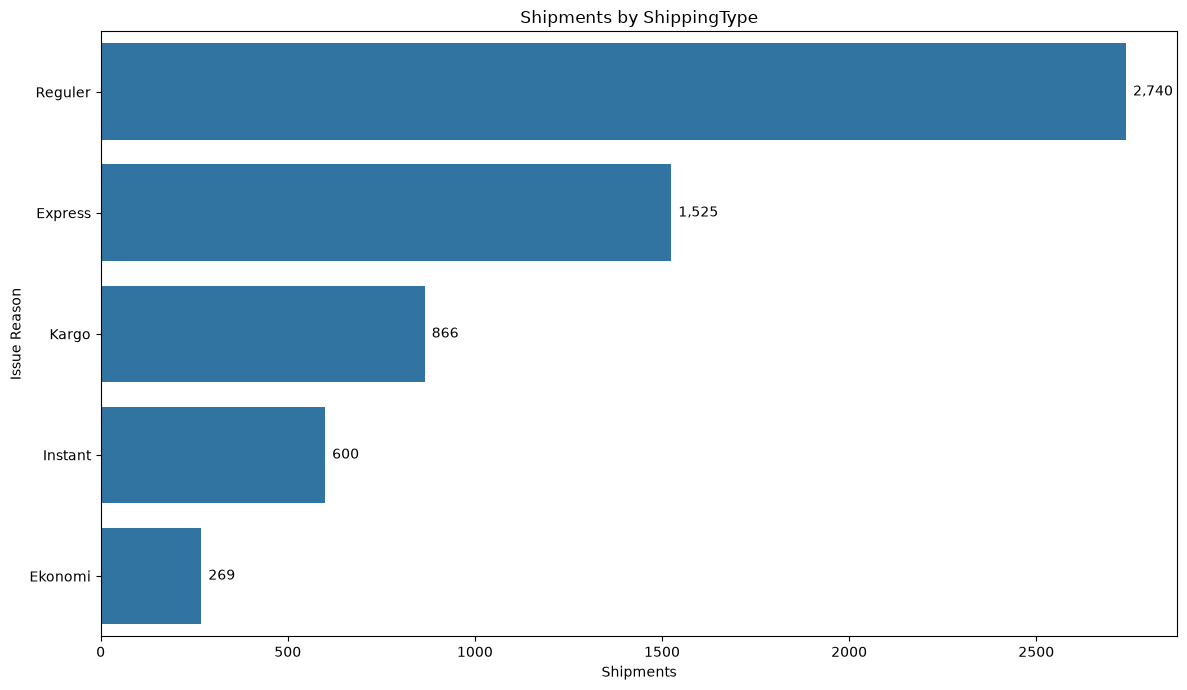

In [28]:
fig = plt.subplots(figsize=(12, 7))

ax = sns.barplot(
    data=shippingtype.sort_values(by='Shipments',ascending=False),
    x='Shipments',
    y='ShippingType',
)

plt.title('Shipments by ShippingType')
plt.xlabel('Shipments')
plt.ylabel('Issue Reason')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

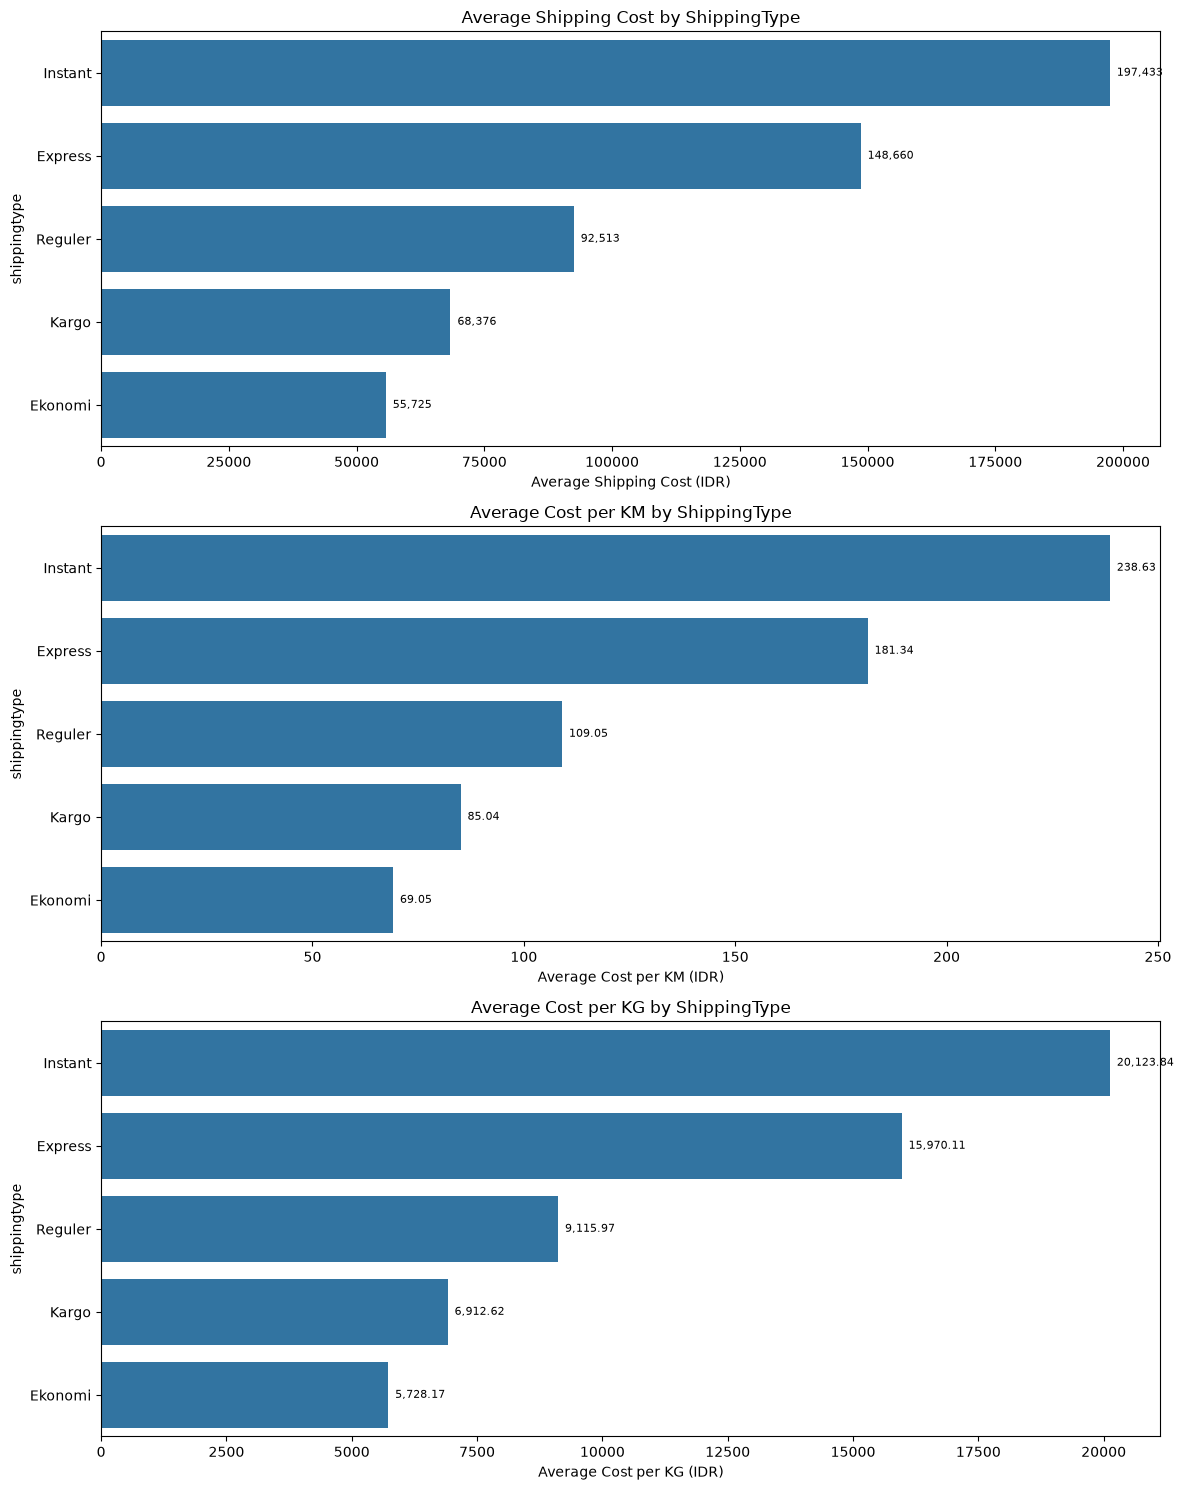

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(data=shippingtype.sort_values(by='AvgCost',ascending=False),
    x='AvgCost',
    y='ShippingType',
    ax=ax[0]
)

ax[0].set_title('Average Shipping Cost by ShippingType')
ax[0].set_xlabel('Average Shipping Cost (IDR)')
ax[0].set_ylabel('shippingtype')

ax[0].bar_label(
    ax[0].containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax[0].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)


sns.barplot(data=shippingtype.sort_values(by='AvgCostPerKM',ascending=False),
    x='AvgCostPerKM',
    y='ShippingType',
    ax=ax[1]
)

ax[1].set_title('Average Cost per KM by ShippingType')
ax[1].set_xlabel('Average Cost per KM (IDR)')
ax[1].set_ylabel('shippingtype')

ax[1].bar_label(
    ax[1].containers[0],
    labels=[
        f'{v:,.2f}'
        for v in ax[1].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)



sns.barplot(data=shippingtype.sort_values(by='AvgCostPerKG',ascending=False),
    x='AvgCostPerKG',
    y='ShippingType',
    ax=ax[2]
)

ax[2].set_title('Average Cost per KG by ShippingType')
ax[2].set_xlabel('Average Cost per KG (IDR)')
ax[2].set_ylabel('shippingtype')

ax[2].bar_label(
    ax[2].containers[0],
    labels=[
        f'{v:,.2f}'
        for v in ax[2].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)

plt.tight_layout()
plt.show()

Carrier x Shipping Type

In [30]:
carriershipping = (
    df.groupby(['Carrier', 'ShippingType'])
    .agg(
        Shipments=('OrderID', 'count'),
        Delivered=('DeliveryStatus', lambda x: (x == 'Delivered').sum()),
        Delayed=('DeliveryStatus', lambda x: (x == 'Delayed').sum()),
        Returned=('DeliveryStatus', lambda x: (x == 'Returned').sum()),
        Lost=('DeliveryStatus', lambda x: (x == 'Lost').sum())
    )
    .reset_index()
)

carriershipping['DeliveryRate'] = (
    carriershipping['Delivered']
    / carriershipping['Shipments']
    * 100
)

carriershipping

,Carrier,ShippingType,Shipments,Delivered,Delayed,Returned,Lost,DeliveryRate
0,AnterAja,Ekonomi,39,26,7,3,3,66.67
1,AnterAja,Express,148,110,28,5,5,74.32
2,AnterAja,Instant,76,54,16,4,2,71.05
3,AnterAja,Kargo,91,60,17,8,6,65.93
4,AnterAja,Reguler,279,185,68,18,8,66.31
5,GoSend Logistics,Ekonomi,28,21,2,2,3,75.00
6,GoSend Logistics,Express,159,112,37,9,1,70.44
7,GoSend Logistics,Instant,57,29,19,7,2,50.88
8,GoSend Logistics,Kargo,73,48,16,6,3,65.75
9,GoSend Logistics,Reguler,283,201,61,15,6,71.02


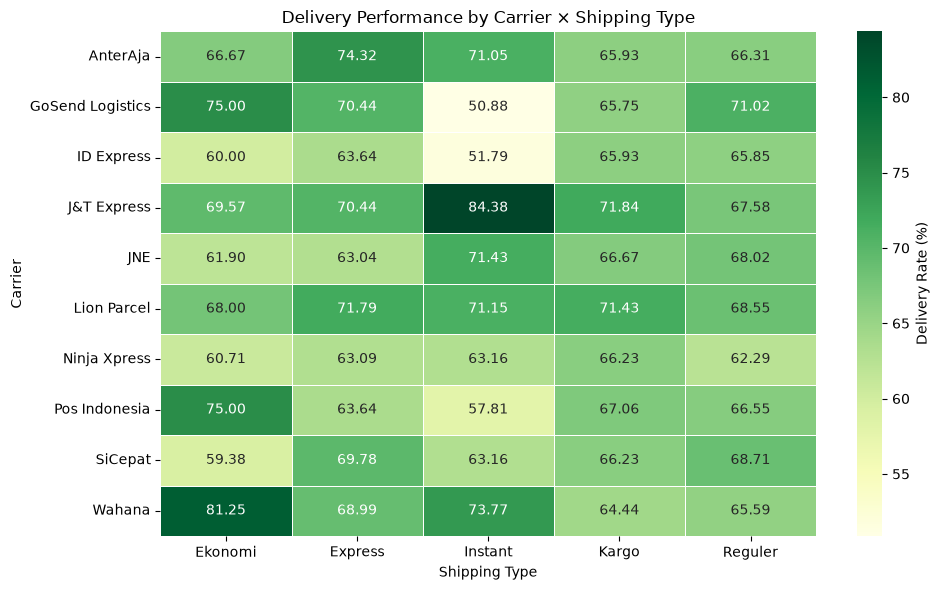

In [31]:
plt.figure(figsize=(10, 6))

heatmap_data = carriershipping.pivot(
    index='Carrier',
    columns='ShippingType',
    values='DeliveryRate'
)

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Delivery Rate (%)'}
)

plt.title('Delivery Performance by Carrier × Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Carrier')

plt.tight_layout()
plt.show()

Warehouse Performance

In [32]:
warehouse = (
    df.groupby('WarehouseID')
    .agg(
        Shipments=('OrderID', 'count'),
        Contribution=('OrderID', lambda x: f'{len(x) / totalshipments * 100:.2f}%'),
        WarehouseVolume=('VolumeM3','sum'),
        AvgCost=('TotalShippingCostIDR', 'mean'),
        AvgDeliveryDays=('ActualDeliveryDays', 'mean'),
        AvgRating=('CustomerRating', 'mean')
    )
    .reset_index()
)
warehouse

,WarehouseID,Shipments,Contribution,WarehouseVolume,AvgCost,AvgDeliveryDays,AvgRating
0,WH-JAK-01,771,12.85%,74.73,"120,073.77",4.85,3.46
1,WH-JAK-02,749,12.48%,72.19,"103,789.35",4.88,3.40
2,WH-MAK-01,781,13.02%,70.03,"122,504.80",5.06,3.48
3,WH-MAK-02,733,12.22%,70.11,"109,189.61",4.79,3.36
4,WH-MED-01,748,12.47%,69.82,"112,226.93",5.06,3.42
5,WH-MED-02,701,11.68%,61.34,"108,092.27",4.72,3.45
6,WH-SUR-01,784,13.07%,72.07,"110,352.31",4.97,3.35
7,WH-SUR-02,733,12.22%,66.86,"109,954.00",4.87,3.44


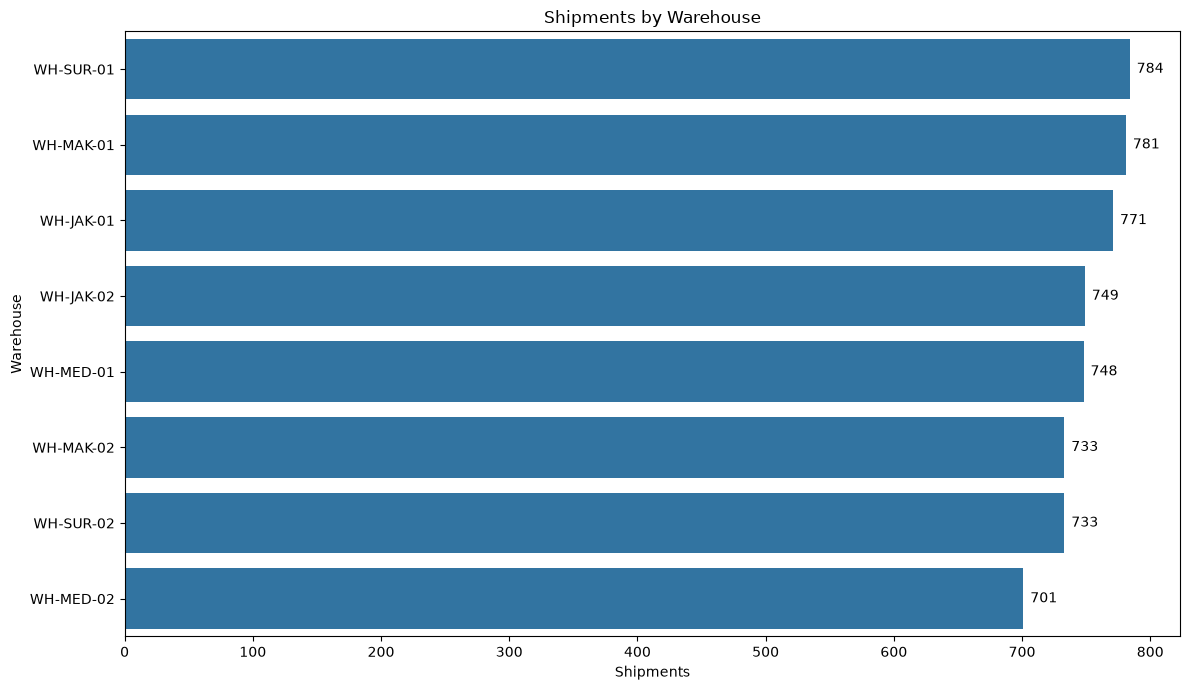

In [33]:
fig = plt.subplots(figsize=(12, 7))

ax = sns.barplot(
    data=warehouse.sort_values(by='Shipments',ascending=False),
    x='Shipments',
    y='WarehouseID',
)

plt.title('Shipments by Warehouse')
plt.xlabel('Shipments')
plt.ylabel('Warehouse')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

Route & Destination

In [34]:
route = (
    df.groupby('Route')
    .agg(
        Shipments=('OrderID', 'count'),
        ShippingVolume=('VolumeM3','sum'),
        AvgDistance=('DistanceKM', 'mean'),
        AvgCost=('TotalShippingCostIDR', 'mean'),
        AvgDeliveryDays=('ActualDeliveryDays', 'mean'),
        AvgRating=('CustomerRating', 'mean')
    )
    .reset_index()
)
route.sort_values(by='Shipments', ascending=False).head(10)

,Route,Shipments,ShippingVolume,AvgDistance,AvgCost,AvgDeliveryDays,AvgRating
165,PEKANBARU → SEMARANG,41,2.86,"1,554.12","84,280.49",6.03,3.42
74,JAKARTA → DENPASAR,40,4.27,"1,141.35","110,766.25",4.42,3.29
137,MEDAN → SEMARANG,40,3.71,"2,087.42","124,527.76",7.33,3.41
62,DENPASAR → MALANG,39,4.25,353.03,"223,670.93",2.08,3.81
44,BATAM → BANJARMASIN,39,3.79,"1,517.92","186,974.89",5.55,3.97
205,YOGYAKARTA → MEDAN,39,3.92,"2,152.85","110,542.31",7.03,3.41
97,MAKASSAR → YOGYAKARTA,39,4.03,"1,250.66","124,754.24",4.32,3.30
151,PALEMBANG → SEMARANG,39,2.74,905.23,"137,542.53",3.82,3.18
21,BANDUNG → MANADO,39,4.89,"2,590.10","157,510.00",8.14,3.94
8,BALIKPAPAN → MEDAN,39,3.62,"2,518.15","118,265.90",7.46,3.68


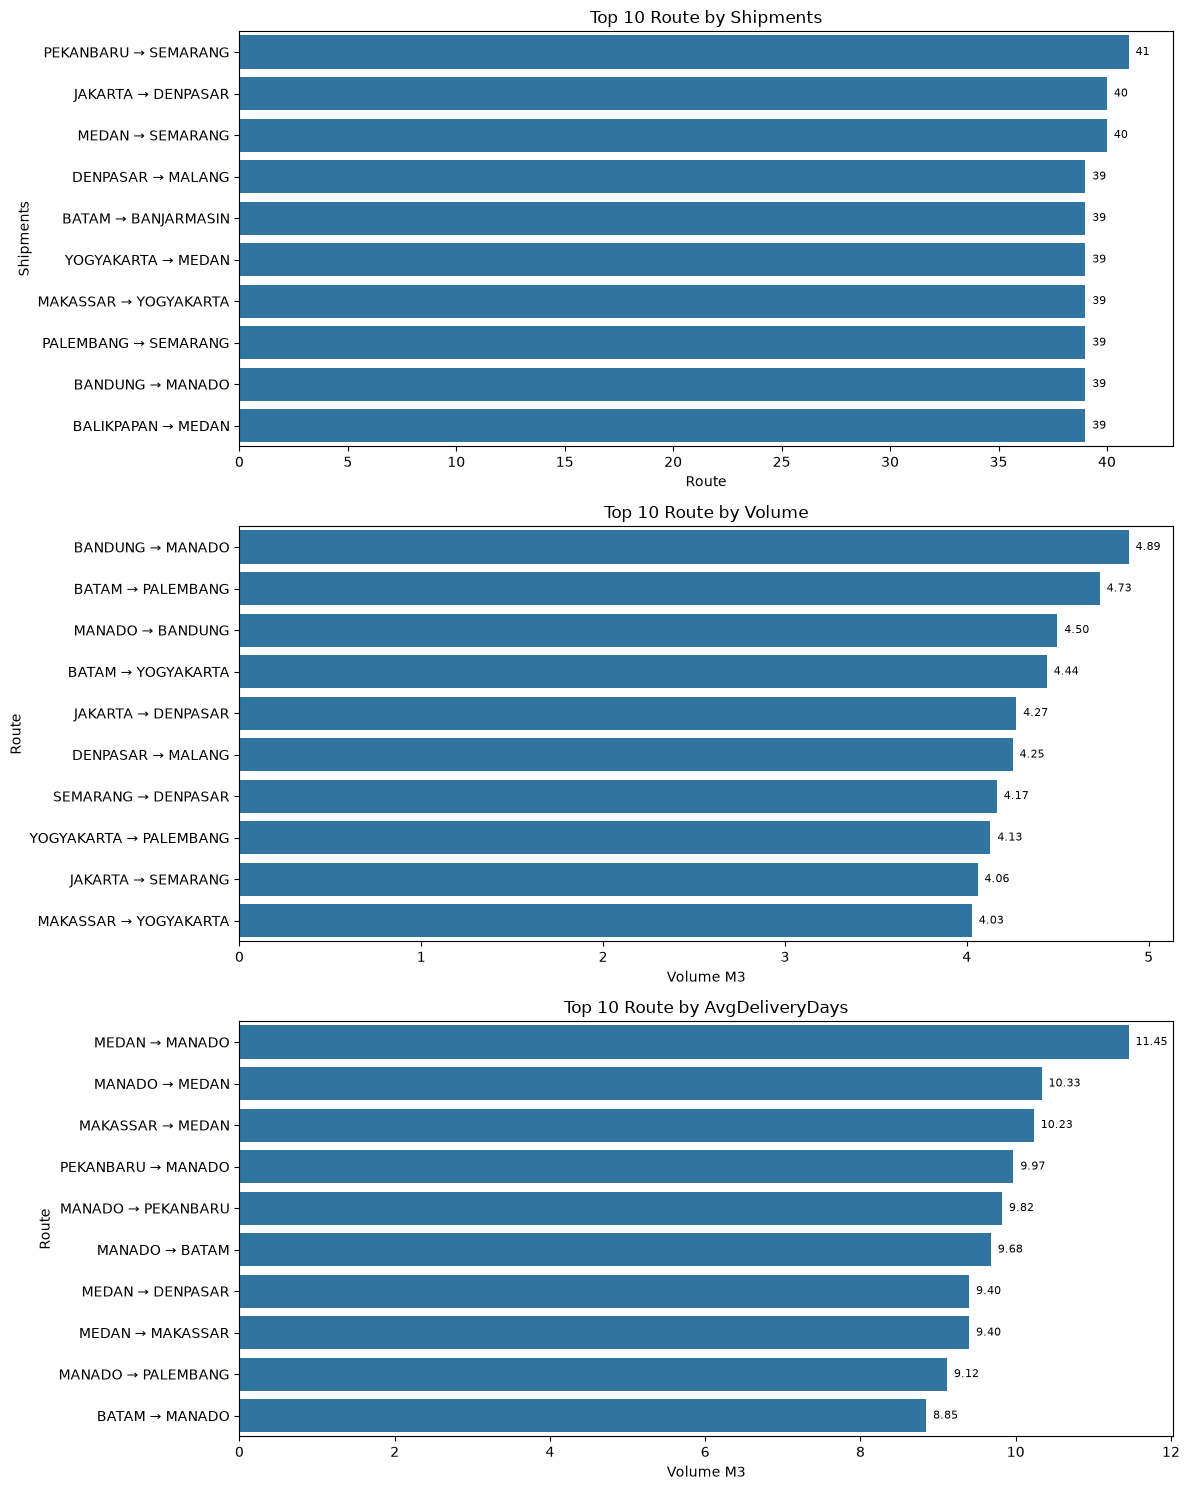

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(data=route.sort_values(by='Shipments',ascending=False).head((10)),
    x='Shipments',
    y='Route',
    ax=ax[0]
)

ax[0].set_title('Top 10 Route by Shipments')
ax[0].set_xlabel('Route')
ax[0].set_ylabel('Shipments')

ax[0].bar_label(
    ax[0].containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax[0].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)

sns.barplot(data=route.sort_values(by='ShippingVolume',ascending=False).head(10),
    x='ShippingVolume',
    y='Route',
    ax=ax[1]
)

ax[1].set_title('Top 10 Route by Volume')
ax[1].set_xlabel('Volume M3')
ax[1].set_ylabel('Route')

ax[1].bar_label(
    ax[1].containers[0],
    labels=[
        f'{v:,.2f}'
        for v in ax[1].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)

sns.barplot(data=route.sort_values(by='AvgDeliveryDays',ascending=False).head(10),
    x='AvgDeliveryDays',
    y='Route',
    ax=ax[2]
)

ax[2].set_title('Top 10 Route by AvgDeliveryDays')
ax[2].set_xlabel('Volume M3')
ax[2].set_ylabel('Route')

ax[2].bar_label(
    ax[2].containers[0],
    labels=[
        f'{v:,.2f}'
        for v in ax[2].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)


plt.tight_layout()
plt.show()

In [36]:
destinationcity = (
    df.groupby('DestinationCity')
    .agg(
        Shipments=('OrderID', 'count'),
        AvgRating=('CustomerRating', 'mean')
    )
    .reset_index()
)
destinationcity.sort_values(by='Shipments', ascending=False)

,DestinationCity,Shipments,AvgRating
12,SEMARANG,443,3.32
14,YOGYAKARTA,438,3.46
8,MANADO,425,3.47
4,DENPASAR,421,3.43
1,BANDUNG,420,3.55
11,PEKANBARU,406,3.29
2,BANJARMASIN,394,3.40
9,MEDAN,394,3.43
3,BATAM,389,3.47
7,MALANG,385,3.44


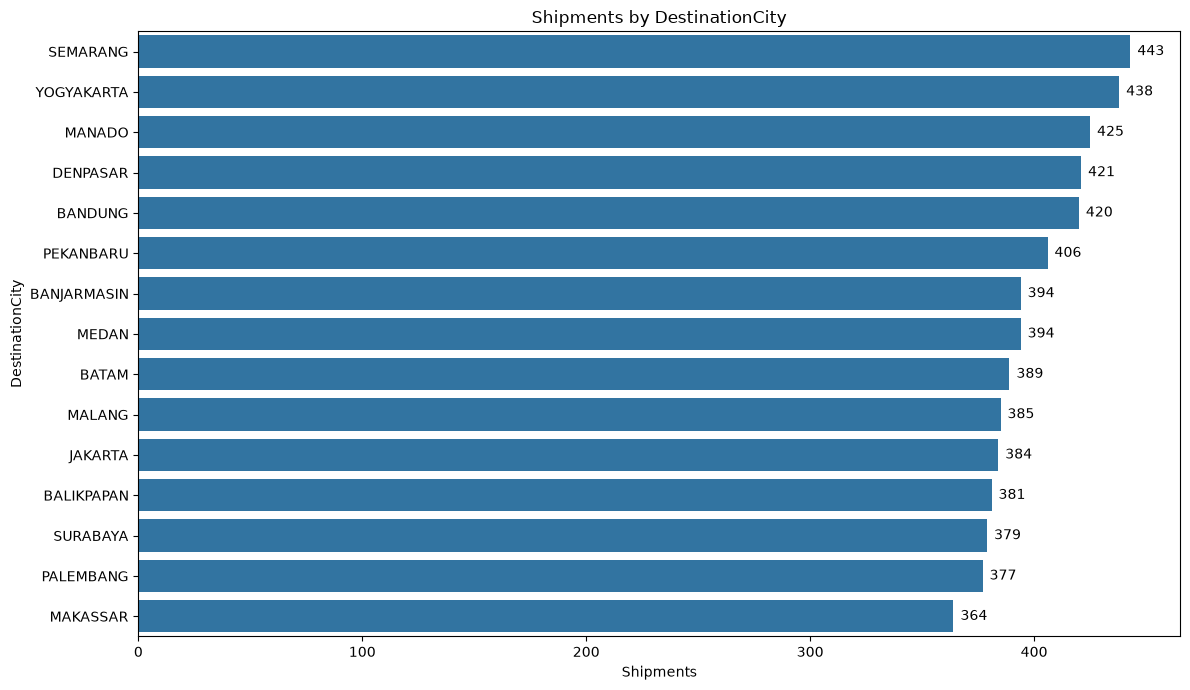

In [37]:
fig = plt.subplots(figsize=(12, 7))

ax = sns.barplot(
    data=destinationcity.sort_values(by='Shipments',ascending=False),
    x='Shipments',
    y='DestinationCity',
)

plt.title('Shipments by DestinationCity')
plt.xlabel('Shipments')
plt.ylabel('DestinationCity')

ax.bar_label(
    ax.containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax.containers[0].datavalues
    ],
    padding=5
)

plt.tight_layout()
plt.show()

Driver Performance

In [38]:
driver = (
    df.groupby('DriverID')
    .agg(
        Shipments=('OrderID', 'count'),
        DriverContribution=('OrderID', lambda x: f'{len(x) / totalshipments * 100:.2f}%'),
        Delivered = ('DeliveryStatus', lambda x: (x == 'Delivered').sum()),
        Delayed = ('DeliveryStatus', lambda x: (x == 'Delayed').sum()),
        Returned = ('DeliveryStatus', lambda x: (x == 'Returned').sum()),
        Lost = ('DeliveryStatus', lambda x: (x == 'Lost').sum()),
        AvgCost = ('TotalShippingCostIDR', 'mean'),
        AvgDeliveryDays=('ActualDeliveryDays', 'mean'),
        AvgRating=('CustomerRating', 'mean')
    )
    .reset_index()
)
driver['DeliveredRate'] = (
    driver['Delivered']
    / driver['Shipments']
    * 100
)
driver['IssueRate'] = (
    driver['Delayed']
    + driver['Returned']
    + driver['Lost']
) / driver['Shipments'] * 100
driver.sort_values(by='Shipments', ascending=False).head(10)

,DriverID,Shipments,DriverContribution,Delivered,Delayed,Returned,Lost,AvgCost,AvgDeliveryDays,AvgRating,DeliveredRate,IssueRate
153,DRV-253,32,0.53%,20,9,2,1,"76,542.50",4.84,2.97,62.50,37.50
351,DRV-451,26,0.43%,17,7,1,1,"97,446.92",5.32,3.46,65.38,34.62
4,DRV-104,26,0.43%,20,4,2,0,"95,594.62",4.96,3.12,76.92,23.08
76,DRV-176,25,0.42%,12,9,3,1,"107,729.20",5.62,2.65,48.00,52.00
28,DRV-128,25,0.42%,17,6,2,0,"120,690.00",4.04,3.52,68.00,32.00
88,DRV-188,25,0.42%,17,5,1,2,"64,213.60",3.65,3.57,68.00,32.00
75,DRV-175,24,0.40%,14,8,1,1,"89,329.17",5.22,3.10,58.33,41.67
207,DRV-307,24,0.40%,19,3,0,2,"105,123.75",4.68,3.10,79.17,20.83
383,DRV-483,23,0.38%,14,8,1,0,"115,985.65",4.43,2.91,60.87,39.13
170,DRV-270,23,0.38%,15,3,5,0,"82,153.04",6.22,3.35,65.22,34.78


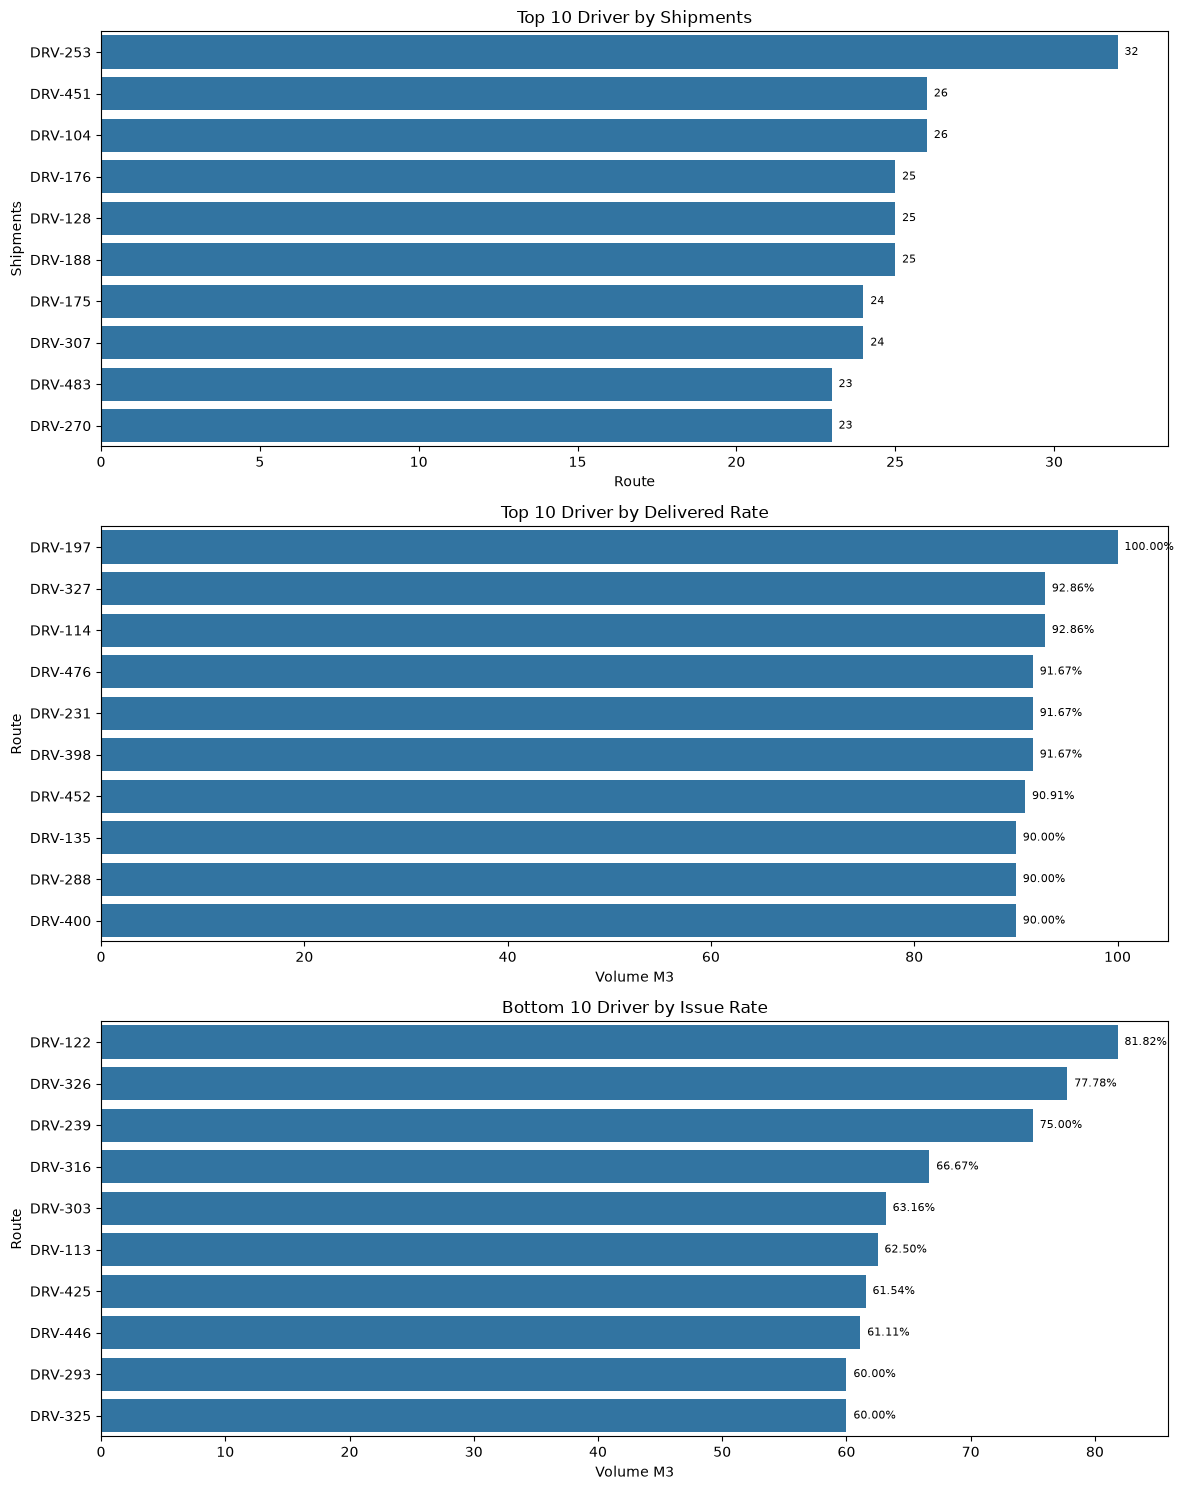

In [39]:
fig, ax = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(data=driver.sort_values(by='Shipments',ascending=False).head((10)),
    x='Shipments',
    y='DriverID',
    ax=ax[0]
)

ax[0].set_title('Top 10 Driver by Shipments')
ax[0].set_xlabel('Route')
ax[0].set_ylabel('Shipments')

ax[0].bar_label(
    ax[0].containers[0],
    labels=[
        f'{int(v):,}'
        for v in ax[0].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)

sns.barplot(data=driver.sort_values(by='DeliveredRate',ascending=False).head(10),
    x='DeliveredRate',
    y='DriverID',
    ax=ax[1]
)

ax[1].set_title('Top 10 Driver by Delivered Rate')
ax[1].set_xlabel('Volume M3')
ax[1].set_ylabel('Route')

ax[1].bar_label(
    ax[1].containers[0],
    labels=[
        f'{v:,.2f}%'
        for v in ax[1].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)

sns.barplot(data=driver.sort_values(by='IssueRate',ascending=False).head(10),
    x='IssueRate',
    y='DriverID',
    ax=ax[2]
)

ax[2].set_title('Bottom 10 Driver by Issue Rate')
ax[2].set_xlabel('Volume M3')
ax[2].set_ylabel('Route')

ax[2].bar_label(
    ax[2].containers[0],
    labels=[
        f'{v:,.2f}%'
        for v in ax[2].containers[0].datavalues
    ],
    padding=5,
    fontsize=8
)


plt.tight_layout()
plt.show()

Correlation

In [40]:
delay_rating_delivered = df[
    df['DeliveryStatus'] == 'Delivered'
][['DelayDays', 'CustomerRating']].dropna()

corr_delivered, p_delivered = pearsonr(
    delay_rating_delivered['DelayDays'],
    delay_rating_delivered['CustomerRating']
)

print('=== Delivered Delay Days Correlation ===')
print('Correlation:', corr_delivered)
print('P-value:', p_delivered)

=== Delivered Delay Days Correlation ===
Correlation: 0.01903689363596
P-value: 0.23168547574054754


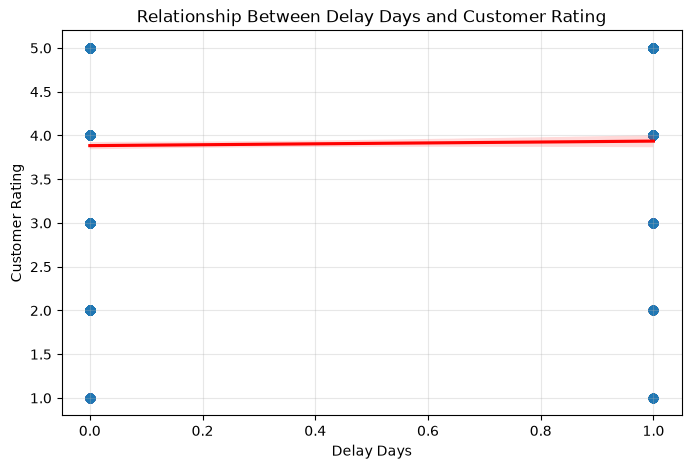

In [41]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=delay_rating_delivered,
    x='DelayDays',
    y='CustomerRating',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title('Relationship Between Delay Days and Customer Rating')
plt.xlabel('Delay Days')
plt.ylabel('Customer Rating')
plt.grid(alpha=0.3)
plt.show()

In [42]:
distance_delivery = df[
    df['ActualDeliveryDays'].notna()
][['DistanceKM', 'ActualDeliveryDays']].dropna()

corr_distance_time, p_distance_time = pearsonr(
    distance_delivery['DistanceKM'],
    distance_delivery['ActualDeliveryDays']
)

print('=== Distance vs Delivery Time ===')
print('Correlation:', corr_distance_time)
print('P-value:', p_distance_time)

=== Distance vs Delivery Time ===
Correlation: 0.7343831602022538
P-value: 0.0


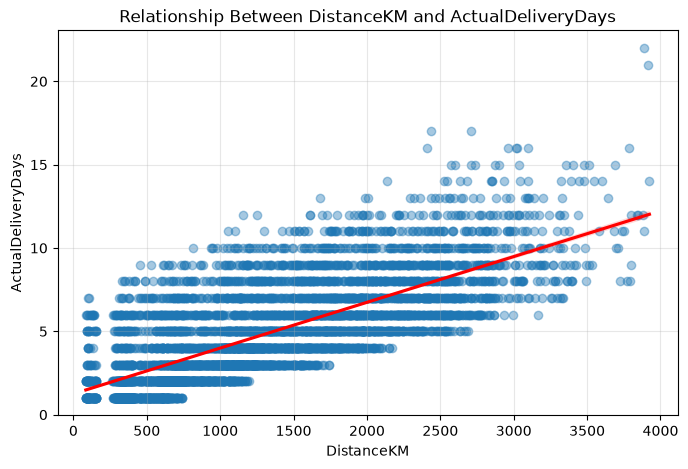

In [43]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=distance_delivery,
    x='DistanceKM',
    y='ActualDeliveryDays',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title('Relationship Between DistanceKM and ActualDeliveryDays')
plt.xlabel('DistanceKM')
plt.ylabel('ActualDeliveryDays')
plt.grid(alpha=0.3)
plt.show()

In [44]:
distance_cost = df[
    ['DistanceKM', 'TotalShippingCostIDR']
].dropna()

corr_distance_cost, p_distance_cost = pearsonr(
    distance_cost['DistanceKM'],
    distance_cost['TotalShippingCostIDR']
)

print('=== Distance vs Shipping Cost ===')
print('Correlation:', corr_distance_cost)
print('P-value:', p_distance_cost)

=== Distance vs Shipping Cost ===
Correlation: 0.04205264338802863
P-value: 0.001121425860953767


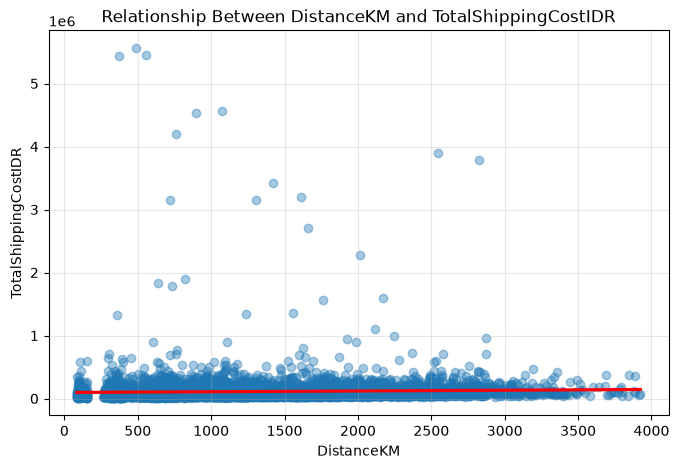

In [45]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=distance_cost,
    x='DistanceKM',
    y='TotalShippingCostIDR',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title('Relationship Between DistanceKM and TotalShippingCostIDR')
plt.xlabel('DistanceKM')
plt.ylabel('TotalShippingCostIDR')
plt.grid(alpha=0.3)
plt.show()